In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

In [3]:
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=0.1736, std=0.3317),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomVerticalFlip(p=0.5),
    torchvision.transforms.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
        )
])

target_transform = lambda y: 1 if y < 10 else 0  # 0 = digit, 1 = letter

test_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=0.1736, std=0.3317),
])

In [ ]:
train = torchvision.datasets.EMNIST(root='/u/zup7mn/Classes/NN/digit4/src/data',
                                    split='byclass',
                                    download=True,
                                    train=True,
                                    transform=train_transforms,
                                    target_transform=target_transform)
test = torchvision.datasets.EMNIST(root='/u/zup7mn/Classes/NN/digit4/src/data',
                                   split='byclass',
                                   download=True,
                                   train=False,
                                   transform=test_transforms,
                                   target_transform=target_transform)

In [ ]:
model = torchvision.models.resnet18()
model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.fc = torch.nn.Linear(512, 1)
model = model.to(device)

In [ ]:
train_loader = torch.utils.data.DataLoader(train, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=1024, shuffle=False, num_workers=4, pin_memory=True)

loss = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
EPOCHS = 20

train_losses = []
test_losses = []

smallest_test_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    loss_epoch = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        preds = model(images).squeeze(1)
        loss_value = loss(preds, labels.float())
        loss_epoch += loss_value.item()
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
    train_losses.append(loss_epoch / len(train_loader))
    print(f"Training Loss: {loss_epoch / len(train_loader)}")

    test_loss_epoch = 0.0
    for test_images, test_labels in test_loader:

        test_images, test_labels = test_images.to(device), test_labels.to(device)
        test_preds = model(test_images).squeeze(1)
        test_loss_value = loss(test_preds, test_labels.float())
        test_loss_epoch += test_loss_value.item()
    test_losses.append(test_loss_epoch / len(test_loader))

    if test_loss_epoch / len(test_loader) < smallest_test_loss:
        smallest_test_loss = test_loss_epoch / len(test_loader)
        torch.save(model.state_dict(), 'best_model.pth')
    torch.save(model.state_dict(), 'last_model.pth')

    print(f"Test Loss: {test_loss_epoch / len(test_loader)}")


Epoch 1/5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [02:13<00:00,  5.10it/s]

Training Loss: 0.3744157462700371


Test Loss: 0.27754660264441844
Epoch 2/5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [03:28<00:00,  3.27it/s]

...

Training Loss: 0.24529213078123382


Test Loss: 0.24554531459222761
Epoch 5/5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [02:13<00:00,  5.11it/s]

Training Loss: 0.23773126697435407


Test Loss: 0.2396547570824623


In [9]:
torch.save(model.state_dict(), 'last_model.pth')

In [10]:
import os
os.getcwd()

'/u/zup7mn'

In [ ]:
## test accuracy

import numpy as np

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_probs = []
all_labels = []

for test_images, test_labels in test_loader:
    test_images, test_labels = test_images.to(device), test_labels.to(device)
    test_preds = model(test_images).squeeze(1)
    all_probs.extend(torch.sigmoid(test_preds).detach().cpu().numpy())
    all_labels.extend(test_labels.detach().cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)


In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)  # area under PR curve

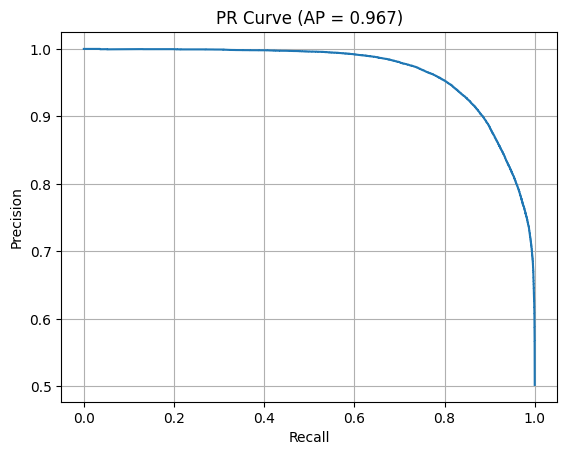

: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AP = {ap:.3f})")
plt.grid(True)
plt.show()